In [2]:
datasets = ['CUB', 'Derm7pt', 'RIVAL10']
use_dataset = datasets[2]

In [3]:
import os
import sys

notebook_dir = os.getcwd()
project_root_path = os.path.dirname(notebook_dir)
sys.path.insert(0, project_root_path)

from src.config import PROJECT_ROOT, CUB_CONFIG, DERM7PT_CONFIG, RIVAL10_CONFIG  # noqa: E402
import numpy as np  # noqa: E402

In [4]:
DATASET_PATH =  os.path.join(PROJECT_ROOT, 'output', use_dataset)
if use_dataset == 'CUB':
    config_dict = CUB_CONFIG
elif use_dataset == 'Derm7pt':
    config_dict = DERM7PT_CONFIG
else:
    config_dict = RIVAL10_CONFIG

In [5]:
num_concepts = config_dict['N_TRIMMED_CONCEPTS']
num_classes = config_dict['N_CLASSES']

# Load and Transform Data

In [6]:
prototypes = np.load(os.path.join(DATASET_PATH, 'learned_prototypes.npy'))

In [7]:
prototypes

array([[0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 1., 0., 0., 0., 0.,
        0., 1.],
       [1., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
        0., 1.],
       [1., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
        0., 0.],
       [1., 0., 0., 0., 0., 0., 1., 0., 1., 1., 0., 1., 0., 0., 0., 0.,
        0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
        0., 1.],
       [0., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1.,
        1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 0.],
       [0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 1.,
        1., 0.]], dtype=float32)

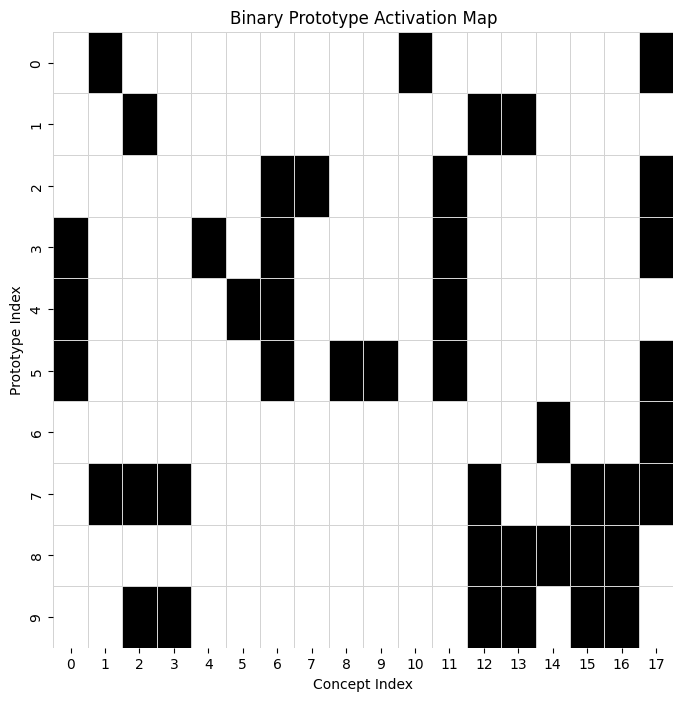

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
sns.heatmap(prototypes, cmap='Greys', cbar=False, linewidths=0.5, linecolor='lightgray')
plt.xlabel("Concept Index")
plt.ylabel("Prototype Index")
plt.title("Binary Prototype Activation Map")
plt.show()

# Spectral Co-Clustering

In [9]:
row_sums = prototypes.sum(axis=1)
col_sums = prototypes.sum(axis=0)

prototypes[row_sums == 0, :] = 1e-10
prototypes[:, col_sums == 0] = 1e-10

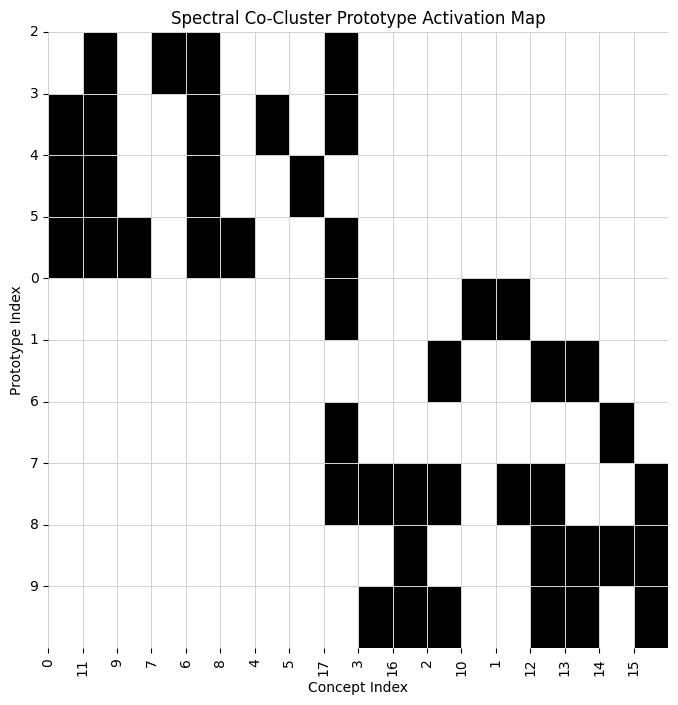

In [10]:
from sklearn.cluster import SpectralCoclustering

if use_dataset =='CUB':
    k = 3
else:
    k = 2

model = SpectralCoclustering(n_clusters=k, random_state=0)
model.fit(prototypes)

row_perm = np.argsort(model.row_labels_)
col_perm = np.argsort(model.column_labels_)

# Apply permutation to matrix
spectral_prototypes = prototypes[row_perm][:, col_perm]

# Plot with correct original indices as ticks
plt.figure(figsize=(8,8))
sns.heatmap(spectral_prototypes, cmap='Greys', cbar=False,
            linewidths=0.5, linecolor='lightgray')

plt.xlabel("Concept Index")
plt.ylabel("Prototype Index")

# Set ticks to original indices (after reordering)
plt.yticks(ticks=np.arange(len(row_perm)), labels=row_perm, rotation=0)
plt.xticks(ticks=np.arange(len(col_perm)), labels=col_perm, rotation=90)

plt.title("Spectral Co-Cluster Prototype Activation Map")
plt.show()

## Analyse Clusters

In [11]:
import pandas as pd
from src.utils.helpers import load_concept_names
from src.preprocessing.concept_processing import select_common_concepts

concept_names_path = os.path.join(PROJECT_ROOT, 'data', 'CUB', 'concepts.txt')

concept_names = load_concept_names(concept_names_path)

cub_concepts = select_common_concepts(None, None, CUB=True)

labels_file = os.path.join(PROJECT_ROOT, 'data', 'CUB', 'classes.txt')
class_names = pd.read_csv(labels_file, sep=' ', header=None, names=['class_id', 'class_name'])

In [12]:
class_names.iloc[0]['class_name']

'001.Black_footed_Albatross'

In [13]:
import pandas as pd

# Let's assume you have these names from your original data
# If you don't, you can just use the indices
row_names = [f'{class_names.iloc[i]["class_name"]}' for i in range(prototypes.shape[0])]
concept_names = [f'{concept_names[cub_concepts[i]]}' for i in range(prototypes.shape[1])]

# Create a DataFrame to hold the results for easy analysis
row_cluster_info = pd.DataFrame({
    'row_name': row_names,
    'cluster_id': model.row_labels_
})

col_cluster_info = pd.DataFrame({
    'concept_name': concept_names,
    'cluster_id': model.column_labels_
})

# Now, group by cluster and see the members
for cluster_id in range(k):
    print(f"--- ROW CLUSTER {cluster_id} ---")
    members = row_cluster_info[row_cluster_info['cluster_id'] == cluster_id]['row_name'].tolist()
    print(members)
    print("\n")

for cluster_id in range(k):
    print(f"--- COLUMN (CONCEPT) CLUSTER {cluster_id} ---")
    members = col_cluster_info[col_cluster_info['cluster_id'] == cluster_id]['concept_name'].tolist()
    print(members)
    print("\n")

--- ROW CLUSTER 0 ---
['003.Sooty_Albatross', '004.Groove_billed_Ani', '005.Crested_Auklet', '006.Least_Auklet']


--- ROW CLUSTER 1 ---
['001.Black_footed_Albatross', '002.Laysan_Albatross', '007.Parakeet_Auklet', '008.Rhinoceros_Auklet', '009.Brewer_Blackbird', '010.Red_winged_Blackbird']


--- COLUMN (CONCEPT) CLUSTER 0 ---
['has_bill_shape::curved_(up_or_down)', 'has_wing_color::blue', 'has_wing_color::rufous', 'has_wing_color::grey', 'has_wing_color::orange', 'has_wing_color::black', 'has_wing_color::red', 'has_upperparts_color::rufous', 'has_underparts_color::rufous']


--- COLUMN (CONCEPT) CLUSTER 1 ---
['has_bill_shape::needle', 'has_bill_shape::spatulate', 'has_bill_shape::all-purpose', 'has_upperparts_color::blue', 'has_upperparts_color::grey', 'has_upperparts_color::orange', 'has_upperparts_color::black', 'has_upperparts_color::red', 'has_underparts_color::blue']




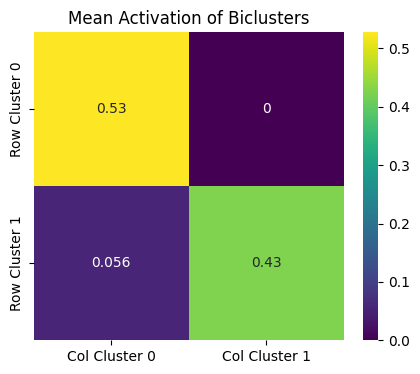

Bicluster Mean Activations:
 [[0.52777779 0.        ]
 [0.05555556 0.42592594]]


In [14]:
# Get the boundaries of the clusters in the reordered matrix
row_cluster_sizes = np.bincount(model.row_labels_)
col_cluster_sizes = np.bincount(model.column_labels_)

# Cumulative sums to find the indices where clusters change
row_boundaries = np.insert(np.cumsum(row_cluster_sizes), 0, 0)
col_boundaries = np.insert(np.cumsum(col_cluster_sizes), 0, 0)

# Create a matrix to store the average activation of each bicluster
bicluster_means = np.zeros((k, k))

for i in range(k): # Row cluster index
    for j in range(k): # Column cluster index

        # Get the slice for this block from the reordered matrix
        row_start, row_end = row_boundaries[i], row_boundaries[i+1]
        col_start, col_end = col_boundaries[j], col_boundaries[j+1]

        block = spectral_prototypes[row_start:row_end, col_start:col_end]

        # Avoid division by zero if a cluster is empty
        if block.size > 0:
            bicluster_means[i, j] = block.mean()

# Visualize the bicluster means
plt.figure(figsize=(5, 4))
sns.heatmap(bicluster_means, annot=True, cmap='viridis',
            xticklabels=[f'Col Cluster {i}' for i in range(k)],
            yticklabels=[f'Row Cluster {i}' for i in range(k)])
plt.title("Mean Activation of Biclusters")
plt.show()

print("Bicluster Mean Activations:\n", bicluster_means)

# NMF

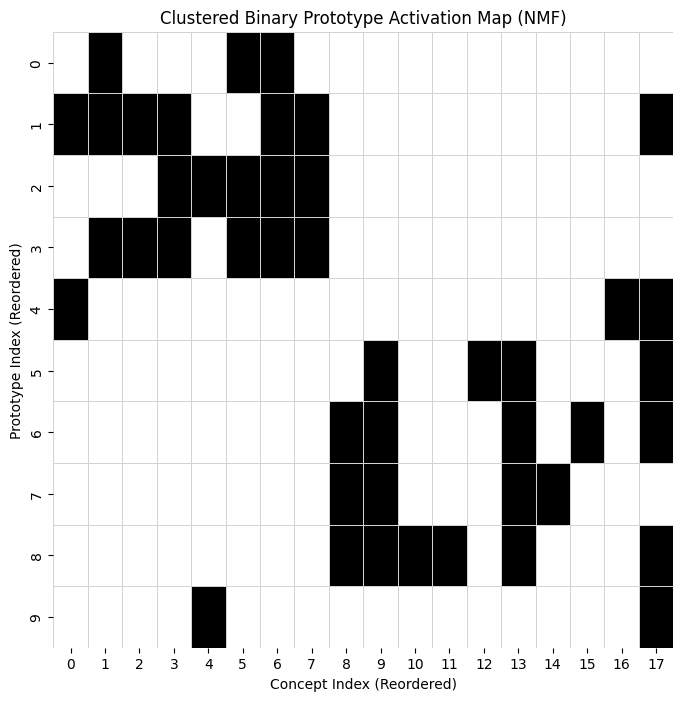

In [15]:
from sklearn.decomposition import NMF
import numpy as np

# Ensure matrix is float and non-negative
X = prototypes.astype(float)

model = NMF(n_components=k, init='nndsvd', random_state=0)
W = model.fit_transform(X)   # shape: (200, k)
H = model.components_        # shape: (k, 112)

# Reorder rows by their dominant component
row_order = np.argsort(np.argmax(W, axis=1))

# Reorder columns by their dominant component
col_order = np.argsort(np.argmax(H, axis=0))

# Reordered matrix
X_reordered = X[row_order][:, col_order]

# Plot it
plt.figure(figsize=(8, 8))
sns.heatmap(X_reordered, cmap='Greys', cbar=False, linewidths=0.5, linecolor='lightgray')
plt.xlabel("Concept Index (Reordered)")
plt.ylabel("Prototype Index (Reordered)")
plt.title("Clustered Binary Prototype Activation Map (NMF)")
plt.show()

array([0.43835698, 0.54648895, 0.92233546, 1.15962527, 0.86163775,
       1.25220349, 0.38580855, 1.22148981, 0.80791753, 1.05311084])

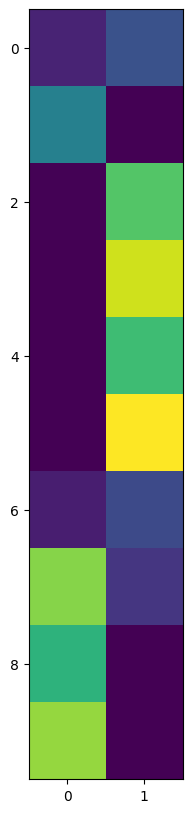

In [16]:
plt.figure(figsize=(10,10))
plt.imshow(W[:50])
np.sum(W, axis=1)

In [17]:
import pandas as pd
import numpy as np
from sklearn.decomposition import NMF

# 1. Get the "hard" cluster labels from the NMF weight matrices.
# The cluster ID for each item is the index of the component with the maximum weight.
nmf_row_labels = np.argmax(W, axis=1)
nmf_col_labels = np.argmax(H, axis=0)

# Create a DataFrame to hold the NMF results
nmf_row_cluster_info = pd.DataFrame({
    'row_name': row_names,
    'cluster_id': nmf_row_labels  # <-- Use the NMF labels
})

nmf_col_cluster_info = pd.DataFrame({
    'concept_name': concept_names,
    'cluster_id': nmf_col_labels  # <-- Use the NMF labels
})

# Now, group by cluster and see the members
print("="*20)
print("  NMF CLUSTER MEMBERS")
print("="*20)

for cluster_id in range(k):
    # Added "NMF" to the printout to distinguish from spectral results
    print(f"--- NMF ROW CLUSTER {cluster_id} ---")
    members = nmf_row_cluster_info[nmf_row_cluster_info['cluster_id'] == cluster_id]['row_name'].tolist()
    print(members)
    print("\n")

for cluster_id in range(k):
    print(f"--- NMF COLUMN (CONCEPT) CLUSTER {cluster_id} ---")
    members = nmf_col_cluster_info[nmf_col_cluster_info['cluster_id'] == cluster_id]['concept_name'].tolist()
    print(members)
    print("\n")

  NMF CLUSTER MEMBERS
--- NMF ROW CLUSTER 0 ---
['002.Laysan_Albatross', '008.Rhinoceros_Auklet', '009.Brewer_Blackbird', '010.Red_winged_Blackbird']


--- NMF ROW CLUSTER 1 ---
['001.Black_footed_Albatross', '003.Sooty_Albatross', '004.Groove_billed_Ani', '005.Crested_Auklet', '006.Least_Auklet', '007.Parakeet_Auklet']


--- NMF COLUMN (CONCEPT) CLUSTER 0 ---
['has_bill_shape::needle', 'has_bill_shape::spatulate', 'has_bill_shape::all-purpose', 'has_upperparts_color::grey', 'has_upperparts_color::orange', 'has_upperparts_color::black', 'has_upperparts_color::red', 'has_underparts_color::blue']


--- NMF COLUMN (CONCEPT) CLUSTER 1 ---
['has_bill_shape::curved_(up_or_down)', 'has_wing_color::blue', 'has_wing_color::rufous', 'has_wing_color::grey', 'has_wing_color::orange', 'has_wing_color::black', 'has_wing_color::red', 'has_upperparts_color::blue', 'has_upperparts_color::rufous', 'has_underparts_color::rufous']




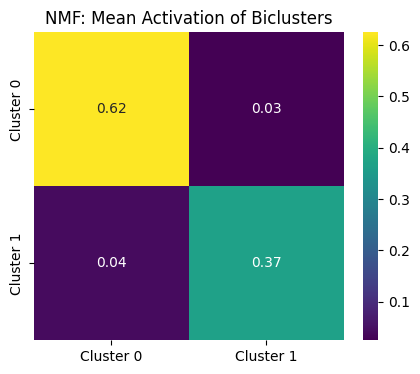

NMF Bicluster Mean Activations:
 [[0.625      0.025     ]
 [0.04166667 0.36666667]]


In [18]:
# 1. Get the "hard" cluster assignments from the soft NMF results
nmf_row_labels = np.argmax(W, axis=1)
nmf_col_labels = np.argmax(H, axis=0)

# 2. Reorder the original matrix based on these cluster assignments
# This is crucial: we analyze the original data, just reordered.
row_order = np.argsort(nmf_row_labels)
col_order = np.argsort(nmf_col_labels)
X_reordered = X[row_order][:, col_order]

# 3. Calculate the boundaries of the clusters in the reordered matrix
# np.bincount will count occurrences of each label (0, 1, 2...)
# It's important to ensure all clusters are represented, even if one is empty
row_cluster_sizes = np.bincount(nmf_row_labels, minlength=k)
col_cluster_sizes = np.bincount(nmf_col_labels, minlength=k)

# Cumulative sums give us the slice indices
row_boundaries = np.insert(np.cumsum(row_cluster_sizes), 0, 0)
col_boundaries = np.insert(np.cumsum(col_cluster_sizes), 0, 0)

# 4. Calculate the mean activation for each block
bicluster_means_nmf = np.zeros((k, k))

for i in range(k): # Row cluster index (Component i)
    for j in range(k): # Column cluster index (Component j)

        # Get the slice for this block from the reordered matrix
        row_start, row_end = row_boundaries[i], row_boundaries[i+1]
        col_start, col_end = col_boundaries[j], col_boundaries[j+1]

        block = X_reordered[row_start:row_end, col_start:col_end]

        # Avoid division by zero if a cluster happens to be empty
        if block.size > 0:
            bicluster_means_nmf[i, j] = block.mean()

# 5. Visualize the result
plt.figure(figsize=(5, 4))
sns.heatmap(bicluster_means_nmf, annot=True, cmap='viridis', fmt='.2f',
            xticklabels=[f'Cluster {i}' for i in range(k)],
            yticklabels=[f'Cluster {i}' for i in range(k)])
plt.title("NMF: Mean Activation of Biclusters")
plt.show()

print("NMF Bicluster Mean Activations:\n", bicluster_means_nmf)

## Comparison

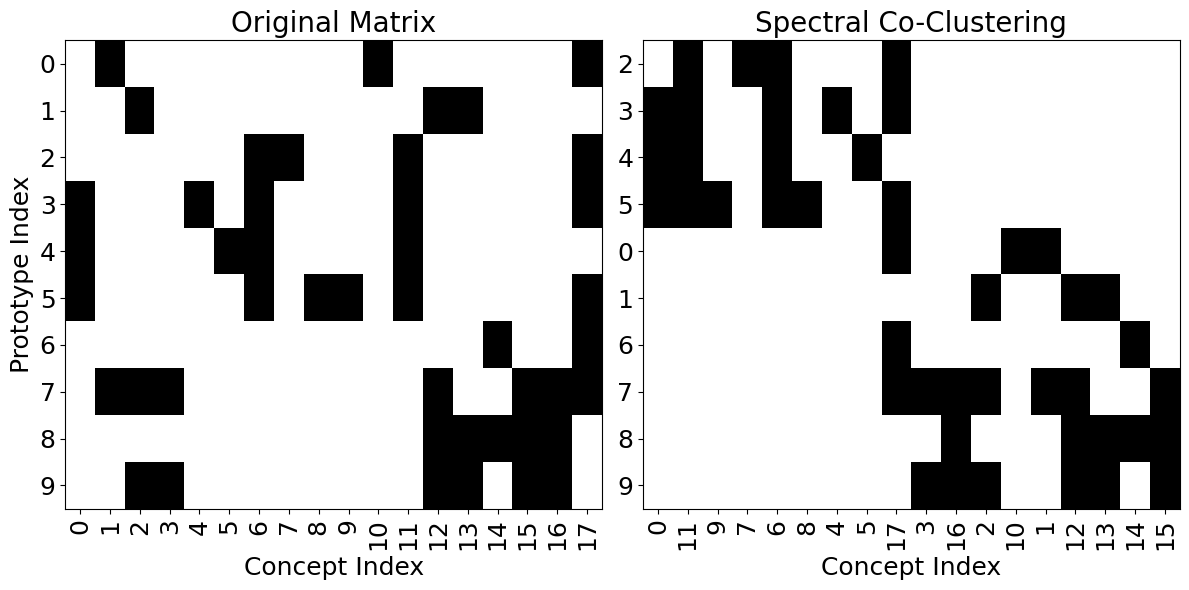

In [19]:
# Create a visualization to compare original prototypes with clustered results
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Original prototypes
axs[0].imshow(prototypes, cmap='binary', aspect='auto')
axs[0].set_title('Original Matrix', fontsize=20)
axs[0].set_xlabel('Concept Index', fontsize=18)
axs[0].set_ylabel('Prototype Index', fontsize=18)

axs[0].set_xticks(ticks=np.arange(len(col_perm)), labels=np.arange(len(col_perm)), rotation=90, fontsize=18)
axs[0].set_yticks(ticks=np.arange(len(row_perm)), labels=np.arange(len(row_perm)), rotation=0, fontsize=18)

# Spectral co-clustering result
axs[1].imshow(spectral_prototypes, cmap='binary', aspect='auto')
axs[1].set_title('Spectral Co-Clustering', fontsize=20)
axs[1].set_xlabel('Concept Index', fontsize=18)
# axs[1].set_ylabel('Prototype Index')


# Set ticks to original indices (after reordering)
axs[1].set_yticks(ticks=np.arange(len(row_perm)), labels=row_perm, rotation=0, fontsize=18)
axs[1].set_xticks(ticks=np.arange(len(col_perm)), labels=col_perm, rotation=90, fontsize=18)

# Genetic algorithm result
# axs[2].imshow(X_reordered, cmap='binary', aspect='auto')
# axs[2].set_title('NMF Clustered Data')
# axs[2].set_xlabel('Concept Index')
# axs[2].set_ylabel('Prototype Index')

plt.tight_layout()
plot_dir = os.path.join(PROJECT_ROOT, 'output', 'plots', 'comparison')
os.makedirs(plot_dir, exist_ok=True)
plt.savefig(os.path.join(plot_dir, f'{use_dataset}_clustering_comparison.png'), dpi=600, bbox_inches='tight')
plt.show()

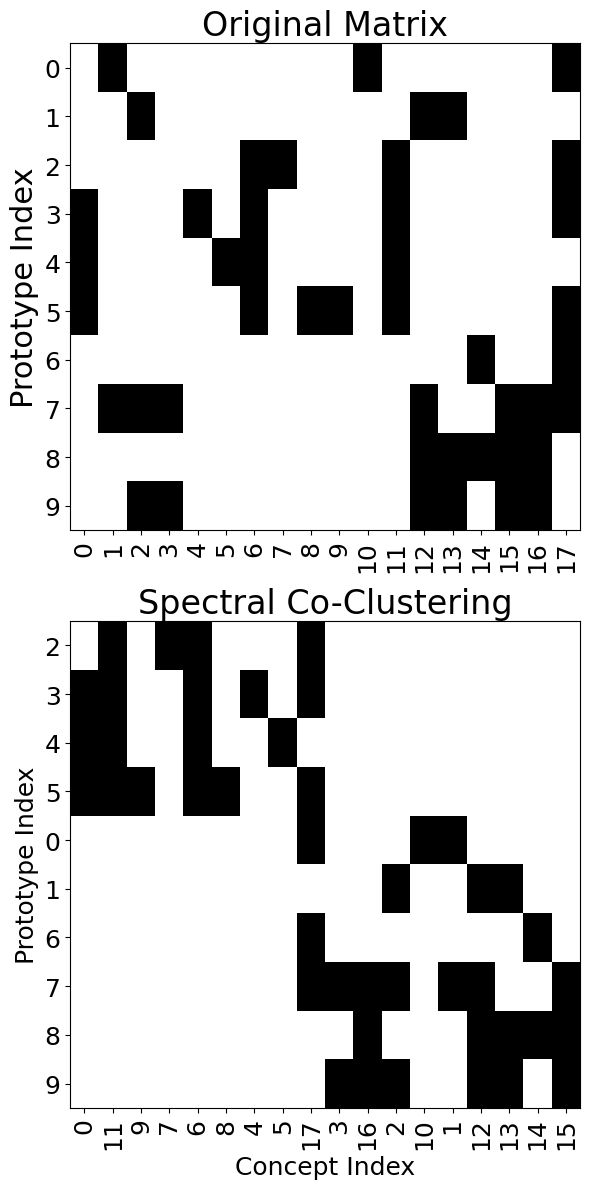

In [ ]:
# Create a visualization to compare original prototypes with clustered results
fig, axs = plt.subplots(2, 1, figsize=(6,12))  # Changed from 1,2 to 2,1 to stack vertically

# Original prototypes
axs[0].imshow(prototypes, cmap='binary', aspect='auto')
axs[0].set_title('Original Matrix', fontsize=24)
# axs[0].set_xlabel('Concept Index', fontsize=18)
axs[0].set_ylabel('Prototype Index', fontsize=22)

axs[0].set_xticks(ticks=np.arange(len(col_perm)), labels=np.arange(len(col_perm)), rotation=90, fontsize=18)
axs[0].set_yticks(ticks=np.arange(len(row_perm)), labels=np.arange(len(row_perm)), rotation=0, fontsize=18)

# Spectral co-clustering result
axs[1].imshow(spectral_prototypes, cmap='binary', aspect='auto')
axs[1].set_title('Spectral Co-Clustering', fontsize=24)
axs[1].set_xlabel('Concept Index', fontsize=22)
axs[1].set_ylabel('Prototype Index', fontsize=22)  # Added this back since it's needed for vertical stacking

# Set ticks to original indices (after reordering)
axs[1].set_yticks(ticks=np.arange(len(row_perm)), labels=row_perm, rotation=0, fontsize=18)
axs[1].set_xticks(ticks=np.arange(len(col_perm)), labels=col_perm, rotation=90, fontsize=18)

plt.tight_layout()
plot_dir = os.path.join(PROJECT_ROOT, 'output', 'plots', 'comparison')
os.makedirs(plot_dir, exist_ok=True)
plt.savefig(os.path.join(plot_dir, f'{use_dataset}_clustering_comparison_vertical.png'), dpi=600, bbox_inches='tight')
plt.show()

## Spectral Co-Clustering
Found 3 clusters
1. Small ground birds
    - sparrows, wrens
    - camouflaged, streaky plumage
    - (concepts) - spotted patterns, blue and red colors, unique head patterns
2. Larger and more conspicuous birds
    - water birds, crows/ravens, woodpeckers, blackbirds
    - (concepts) - very large, long-legged, perching body shapes, multi-colored and striped patterns, specialised bill shapes
3. Colourful songbirds 
    - warblers, buntings, goldfinches, hummingbirds, other brightly coloured birds
    - (concepts) - medium to large birds, striped patterns, rounded tails

## NMF
1. darker/black birds with mixed habitats
    - crows, ravens, blackbirds, water birds (cormorants, grebes), mixed songbirds
    - (concepts) - orange/warm colours, striped patterns
2. small songbirds and perching birds
   - sparrows, warblers, buntings, finches
   - (concepts) - blue/gray/red colours and larger sizes
3. water birds, aerial birds, and larger birds
    - albatross, seabirds, seagulls, hummingbirds, terns
    - (concepts) - dark colors and specific bill shapes


## Differences
SCC focuses more on size-based clustering, with the small birds separated out from larger birds.

SCC separates water-based vs ground-based vs arboreal a bit more clearly.

SCC separates the very colourful birds more.

SCC also more clearly reflects the habitats of the birds.

# Cluster Prototypes, then Concepts

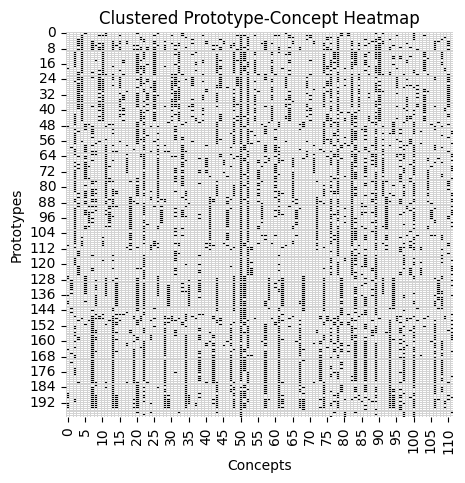

In [19]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, leaves_list

# Compute Jaccard distance between prototypes
dist_prototypes = pdist(prototypes, metric="jaccard")
link_prototypes = linkage(dist_prototypes, method="average")

# Get ordered row indices
row_order = leaves_list(link_prototypes)

# # Compute Jaccard distance between concepts (columns)
# dist_concepts = pdist(prototypes.T, metric="jaccard")
# link_concepts = linkage(dist_concepts, method="average")

# # Get ordered column indices
# col_order = leaves_list(link_concepts)

# Reorder matrix
prototypes_reordered = prototypes[row_order, :]

plt.figure(figsize=(5,5))
sns.heatmap(prototypes_reordered, cmap='Greys', cbar=False, linewidths=0.5, linecolor='lightgray')
plt.xlabel("Concepts")
plt.ylabel("Prototypes")
plt.title("Clustered Prototype-Concept Heatmap")
plt.show()

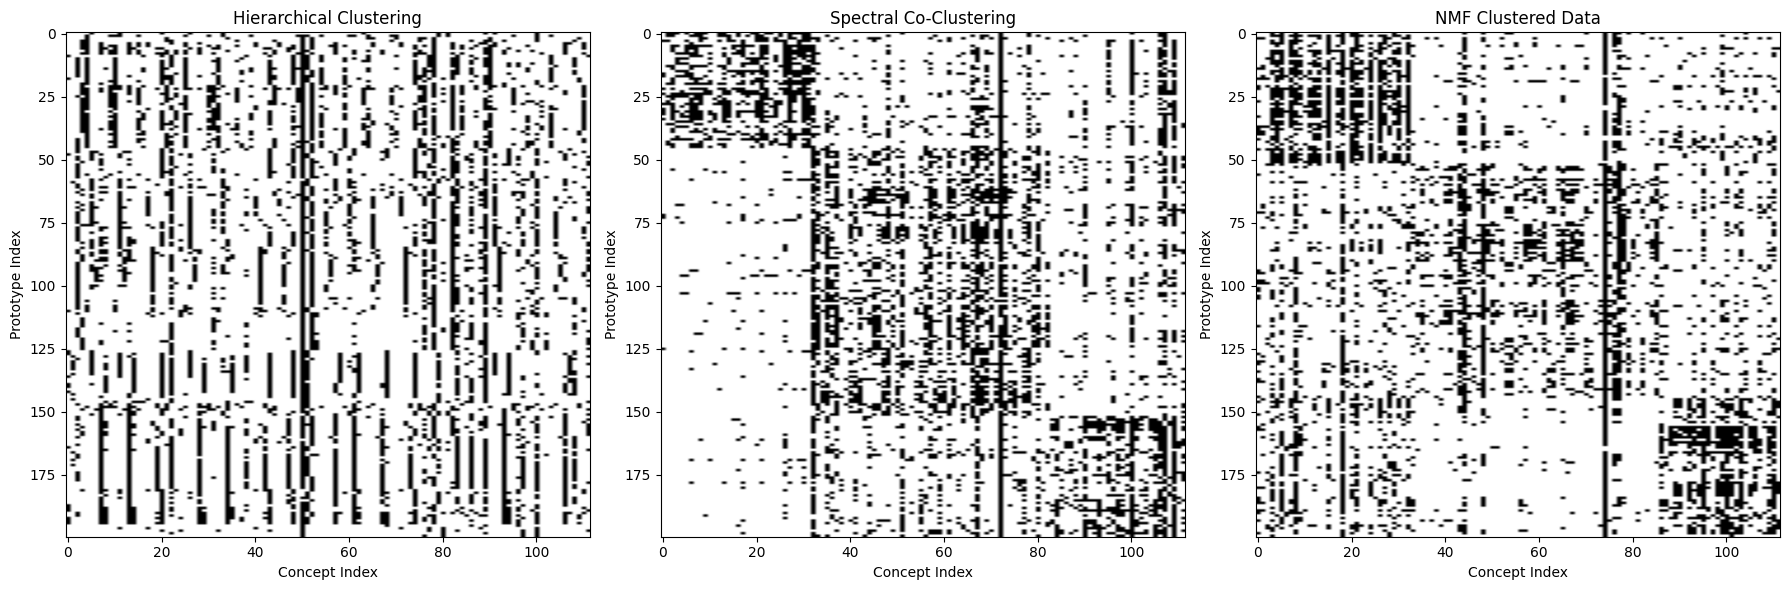

In [20]:
# Create a visualization to compare original prototypes with clustered results
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Original prototypes
axs[0].imshow(prototypes_reordered, cmap='binary', aspect='auto')
axs[0].set_title('Hierarchical Clustering')
axs[0].set_xlabel('Concept Index')
axs[0].set_ylabel('Prototype Index')

# Spectral co-clustering result
axs[1].imshow(spectral_prototypes, cmap='binary', aspect='auto')
axs[1].set_title('Spectral Co-Clustering')
axs[1].set_xlabel('Concept Index')
axs[1].set_ylabel('Prototype Index')

# Genetic algorithm result
axs[2].imshow(X_reordered, cmap='binary', aspect='auto')
axs[2].set_title('NMF Clustered Data')
axs[2].set_xlabel('Concept Index')
axs[2].set_ylabel('Prototype Index')

plt.tight_layout()
# plot_dir = os.path.join(PROJECT_ROOT, 'output', 'plots', 'comparison')
# os.makedirs(plot_dir, exist_ok=True)
# plt.savefig(os.path.join(plot_dir, f'{use_dataset}_clustering_comparison.png'), dpi=600, bbox_inches='tight')
plt.show()

# Genetic Algorithm

In [21]:
# from collections import deque
# import numpy as np
# import random
# import matplotlib.pyplot as plt

# # --- 1. SETUP: Create Sample Data ---
# # This creates a sparse random matrix to simulate your data.
# # Replace this with your actual 'prototypes' data.
# # NUM_ROWS = 50
# # NUM_COLS = 30
# # Using a smaller matrix for faster demonstration
# # prototypes = np.random.choice([0, 1], size=(NUM_ROWS, NUM_COLS), p=[0.8, 0.2])

# # --- GENETIC ALGORITHM PARAMETERS ---
# POPULATION_SIZE = 100
# NUM_GENERATIONS = 1000
# MUTATION_RATE = 0.05
# ELITISM_COUNT = 2
# TOURNAMENT_SIZE = 3
# INVERSION_PROBABILITY = 0.3
# K_BLOBS = 5 # <--- THE NEW KEY PARAMETER: How many top clusters to reward

# # --- 2. CORE GA FUNCTIONS ---

# def create_individual(rows, cols):
#     """Creates a single chromosome with random row and column permutations."""
#     return {
#         'row_perm': np.random.permutation(rows),
#         'col_perm': np.random.permutation(cols)
#     }

# def _find_blob_size_bfs(matrix, visited, start_r, start_c):
#     """Helper function to find the size of a single blob using Breadth-First Search."""
#     rows, cols = matrix.shape
#     if not (0 <= start_r < rows and 0 <= start_c < cols) or visited[start_r, start_c] or matrix[start_r, start_c] == 0:
#         return 0

#     blob_size = 0
#     queue = deque([(start_r, start_c)])
#     visited[start_r, start_c] = True

#     while queue:
#         r, c = queue.popleft()
#         blob_size += 1

#         for dr in [-1, 0, 1]:
#             for dc in [-1, 0, 1]:
#                 if dr == 0 and dc == 0: continue
#                 nr, nc = r + dr, c + dc
#                 if (0 <= nr < rows and 0 <= nc < cols and
#                         not visited[nr, nc] and matrix[nr, nc] == 1):
#                     visited[nr, nc] = True
#                     queue.append((nr, nc))

#     return blob_size

# def calculate_fitness(individual, base_matrix, k_blobs):
#     """
#     Calculates fitness based on the sum of squares of the TOP 'K' LARGEST BLOBS.
#     This encourages the formation of a specific number of large clusters.
#     """
#     rows, cols = base_matrix.shape
#     permuted_matrix = base_matrix[individual['row_perm']][:, individual['col_perm']]

#     visited = np.full(base_matrix.shape, False)
#     blob_sizes = []

#     # Find all blobs and record their sizes
#     for r in range(rows):
#         for c in range(cols):
#             if permuted_matrix[r, c] == 1 and not visited[r, c]:
#                 blob_size = _find_blob_size_bfs(permuted_matrix, visited, r, c)
#                 if blob_size > 0:
#                     blob_sizes.append(blob_size)

#     # Sort the sizes in descending order
#     blob_sizes.sort(reverse=True)

#     # Get the top K blob sizes (or fewer if not enough blobs exist)
#     top_k_sizes = blob_sizes[:k_blobs]

#     # The fitness is the sum of the squares of these top K sizes
#     total_fitness = sum(size ** 2 for size in top_k_sizes)

#     return total_fitness

# def pmx_crossover_1d(p1, p2):
#     """Performs Partially-Mapped Crossover on a single permutation array."""
#     size = len(p1)
#     c1, c2 = -1 * np.ones(size, dtype=int), -1 * np.ones(size, dtype=int)

#     start, end = sorted(random.sample(range(size), 2))

#     c1[start:end] = p1[start:end]
#     c2[start:end] = p2[start:end]

#     map1_to_2 = {p1[i]: p2[i] for i in range(start, end)}
#     map2_to_1 = {p2[i]: p1[i] for i in range(start, end)}

#     for i in list(range(start)) + list(range(end, size)):
#         val = p2[i]
#         while val in c1: val = map1_to_2.get(val, val)
#         c1[i] = val
#         val = p1[i]
#         while val in c2: val = map2_to_1.get(val, val)
#         c2[i] = val

#     return c1, c2

# def crossover(parent1, parent2):
#     """Applies PMX crossover to both row and column permutations."""
#     row_c1, row_c2 = pmx_crossover_1d(parent1['row_perm'], parent2['row_perm'])
#     col_c1, col_c2 = pmx_crossover_1d(parent1['col_perm'], parent2['col_perm'])

#     child1 = {'row_perm': row_c1, 'col_perm': col_c1}
#     child2 = {'row_perm': row_c2, 'col_perm': col_c2}
#     return child1, child2

# def mutate(individual, mutation_rate, inversion_prob):
#     """Performs mutation on row and column permutations."""
#     # Mutate row permutation
#     if random.random() < mutation_rate:
#         perm = individual['row_perm']
#         if random.random() < inversion_prob:
#             start, end = sorted(random.sample(range(len(perm)), 2))
#             perm[start:end+1] = perm[start:end+1][::-1]
#         else:
#             idx1, idx2 = random.sample(range(len(perm)), 2)
#             perm[idx1], perm[idx2] = perm[idx2], perm[idx1]

#     # Mutate column permutation
#     if random.random() < mutation_rate:
#         perm = individual['col_perm']
#         if random.random() < inversion_prob:
#             start, end = sorted(random.sample(range(len(perm)), 2))
#             perm[start:end+1] = perm[start:end+1][::-1]
#         else:
#             idx1, idx2 = random.sample(range(len(perm)), 2)
#             perm[idx1], perm[idx2] = perm[idx2], perm[idx1]
#     return individual

# def tournament_selection(population, fitnesses, k):
#     """Selects a parent using tournament selection."""
#     selected_indices = random.sample(range(len(population)), k)
#     best_index = max(selected_indices, key=lambda i: fitnesses[i])
#     return population[best_index]

# # --- 3. MAIN GENETIC ALGORITHM LOOP ---

# print(f"Starting Genetic Algorithm with Top-{K_BLOBS} Blobs Reward Fitness...")

# population = [create_individual(prototypes.shape[0], prototypes.shape[1]) for _ in range(POPULATION_SIZE)]
# best_fitness_history = []

# for generation in range(NUM_GENERATIONS):
#     # Calculate fitness, passing K_BLOBS to the function
#     fitnesses = [calculate_fitness(ind, prototypes, K_BLOBS) for ind in population]
#     best_fitness_history.append(max(fitnesses))

#     if generation % 10 == 0:
#         print(f"Generation {generation:3}: Best Fitness = {max(fitnesses)}")

#     new_population = []

#     elite_indices = np.argsort(fitnesses)[-ELITISM_COUNT:]
#     for i in elite_indices:
#         new_population.append(population[i])

#     while len(new_population) < POPULATION_SIZE:
#         parent1 = tournament_selection(population, fitnesses, TOURNAMENT_SIZE)
#         parent2 = tournament_selection(population, fitnesses, TOURNAMENT_SIZE)

#         child1, child2 = crossover(parent1, parent2)

#         mutate(child1, MUTATION_RATE, INVERSION_PROBABILITY)
#         mutate(child2, MUTATION_RATE, INVERSION_PROBABILITY)

#         new_population.append(child1)
#         if len(new_population) < POPULATION_SIZE:
#             new_population.append(child2)

#     population = new_population

# print("Genetic Algorithm Finished.")

# # --- 4. VISUALIZE THE RESULTS ---
# final_fitnesses = [calculate_fitness(ind, prototypes, K_BLOBS) for ind in population]
# best_individual = population[np.argmax(final_fitnesses)]
# best_matrix = prototypes[best_individual['row_perm']][:, best_individual['col_perm']]

# fig, axs = plt.subplots(1, 3, figsize=(18, 6))
# axs[0].imshow(prototypes, cmap='binary', aspect='auto')
# axs[0].set_title('Original Matrix')
# axs[0].set_xlabel('Columns')
# axs[0].set_ylabel('Rows')
# axs[1].imshow(best_matrix, cmap='binary', aspect='auto')
# axs[1].set_title(f'Clustered Matrix (Fitness: {max(final_fitnesses)})')
# axs[1].set_xlabel('Reordered Columns')
# axs[1].set_ylabel('Reordered Rows')
# axs[2].plot(best_fitness_history)
# axs[2].set_title('Fitness Improvement Over Generations')
# axs[2].set_xlabel('Generation')
# axs[2].set_ylabel('Best Fitness Score')
# axs[2].grid(True)
# plt.tight_layout()
# plt.show()

In [22]:
# # final_fitnesses = [calculate_fitness(ind, prototypes) for ind in population]
# best_individual = population[np.argmax(final_fitnesses)]
# best_matrix = prototypes[best_individual['row_perm']][:, best_individual['col_perm']]

# fig, axs = plt.subplots(1, 3, figsize=(18, 6))
# axs[0].imshow(prototypes, cmap='binary', aspect='auto')
# axs[0].set_title('Original Matrix')
# axs[0].set_xlabel('Columns')
# axs[0].set_ylabel('Rows')
# axs[1].imshow(best_matrix, cmap='binary', aspect='auto')
# axs[1].set_title(f'Clustered Matrix (Fitness: {max(final_fitnesses)})')
# axs[1].set_xlabel('Reordered Columns')
# axs[1].set_ylabel('Reordered Rows')
# axs[2].plot(best_fitness_history)
# axs[2].set_title('Fitness Improvement Over Generations')
# axs[2].set_xlabel('Generation')
# axs[2].set_ylabel('Best Fitness Score')
# axs[2].grid(True)
# plt.tight_layout()
# plot_dir = os.path.join(PROJECT_ROOT, 'output', 'plots', 'genetic')
# os.makedirs(plot_dir, exist_ok=True)
# plt.savefig(os.path.join(plot_dir, f'{use_dataset}_genetic.png'), dpi=600, bbox_inches='tight')
# plt.show()

In [23]:
# np.save(os.path.join(plot_dir, f'{use_dataset}_genetic_matrix.npy'), best_matrix)
# np.save(os.path.join(plot_dir, f'{use_dataset}_fitness_history.npy'), best_fitness_history)